# Time-Series Axon Break Analysis

Tracks how axon integrity changes **over time** within each CZI file.

### What this notebook does
1. Loads all time points from each `.czi` file
2. Runs Frangi segmentation + break detection at every time point
3. Plots **break rate** and **continuity score** over time per file
4. Compares time courses **across conditions** (mean ± SEM band)
5. Shows selected frames with breaks overlaid so you can visually verify

### Metrics (same as best_method.ipynb)
| Metric | Meaning |
|---|---|
| **Break rate** | breaks per 1000 skeleton px — normalised for axon density |
| **Continuity** | mean segment length (px) — higher = more continuous axons |

In [10]:
from pylibCZIrw import czi as pyczi
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
from skimage.morphology import skeletonize, white_tophat, disk
from skimage.morphology import closing as morpho_closing
from skimage.filters import frangi, gaussian, threshold_otsu
from scipy import ndimage
from scipy.spatial import cKDTree
from skimage.measure import label
from scipy.stats import kruskal
from itertools import combinations
import numpy as np

In [11]:
def find_skeleton_endpoints(skeleton):
    kernel = np.ones((3, 3), dtype=np.uint8)
    kernel[1, 1] = 0
    nc = ndimage.convolve(skeleton.astype(np.uint8), kernel, mode='constant', cval=0)
    return np.argwhere((skeleton > 0) & (nc == 1))

def filter_small_components(skeleton, min_size=30):
    labeled = label(skeleton, connectivity=2)
    sizes = np.bincount(labeled.ravel())
    keep = np.where(sizes >= min_size)[0]
    keep = keep[keep != 0]
    return np.isin(labeled, keep)

def _norm(img):
    f = img.astype(float)
    return (f - f.min()) / (f.max() - f.min() + 1e-8)

In [12]:
def inspect_czi(path):
    """Print shape info so you can verify time dimension ordering."""
    with pyczi.open_czi(path) as cz:
        raw = cz.read()
    img = np.squeeze(raw)
    print(f"File          : {os.path.basename(path)}")
    print(f"Raw shape     : {raw.shape}")
    print(f"Squeezed shape: {img.shape}")
    print(f"Assumed layout: first dim = time ({img.shape[0]} frames)")
    print()
    return img.shape


def load_timeseries(path):
    """
    Load all time points from a CZI file.
    Returns array of shape (T, H, W) — one 2D frame per time point.

    Dimension assumptions after np.squeeze():
      (T, H, W)       — single channel, used as-is
      (T, C, H, W)    — multi-channel, channel 0 taken
      (H, W)          — single frame, wrapped as (1, H, W)

    If your data looks wrong, check inspect_czi() output first.
    """
    with pyczi.open_czi(path) as cz:
        raw = cz.read()
    img = np.squeeze(raw)

    if img.ndim == 2:
        return img[np.newaxis]           # (1, H, W)
    elif img.ndim == 3:
        return img                        # (T, H, W)
    elif img.ndim == 4:
        return img[:, 0]                  # (T, C, H, W) → (T, H, W)
    else:
        raise ValueError(
            f"Unexpected shape {img.shape}. "
            "Run inspect_czi() to see raw dimensions."
        )

In [13]:
def preprocess_frangi(img, sigmas=(1,2,3,4,5), beta=0.5):
    img_smooth = gaussian(_norm(img), sigma=1)
    tube_map   = frangi(img_smooth, sigmas=sigmas, beta=beta, black_ridges=False)
    binary     = morpho_closing(tube_map > threshold_otsu(tube_map))
    return binary, tube_map

def preprocess_tophat(img, radius=10):
    tophat = white_tophat(_norm(img), disk(radius))
    binary = morpho_closing(tophat > threshold_otsu(tophat))
    return binary, tophat

In [14]:
def find_broken_lines(skeleton, min_gap=10, max_gap=100, min_component_size=30):
    skeleton  = filter_small_components(skeleton, min_size=min_component_size).astype(bool)
    endpoints = find_skeleton_endpoints(skeleton)
    if len(endpoints) < 2:
        return [], endpoints
    comp_map  = label(skeleton, connectivity=2)
    ep_labels = np.array([comp_map[r, c] for r, c in endpoints])
    tree = cKDTree(endpoints)
    candidates = []
    for i, j in tree.query_pairs(r=max_gap):
        if ep_labels[i] == ep_labels[j]: continue
        dist = float(np.linalg.norm(endpoints[i] - endpoints[j]))
        if dist >= min_gap:
            candidates.append((dist, i, j))
    candidates.sort()
    used = set(); breaks = []
    for dist, i, j in candidates:
        if i not in used and j not in used:
            used.update([i, j])
            breaks.append({'pt1': tuple(endpoints[i]),
                           'pt2': tuple(endpoints[j]),
                           'distance': dist})
    return breaks, endpoints

def compute_metrics(skeleton, breaks, min_component_size=30):
    skel_clean  = filter_small_components(skeleton, min_size=min_component_size).astype(bool)
    skel_length = int(skel_clean.sum())
    n_comp      = int(label(skel_clean, connectivity=2).max())
    n_breaks    = len(breaks)
    break_rate  = (n_breaks / skel_length * 1000) if skel_length > 0 else 0.0
    continuity  = (skel_length / n_comp)           if n_comp > 0      else 0.0
    return {'n_breaks': n_breaks, 'skel_length': skel_length,
            'break_rate': break_rate, 'n_components': n_comp,
            'continuity': continuity}

In [15]:
def analyze_timeseries(path, method='frangi', min_gap=10, max_gap=100,
                       min_component_size=30, sigmas=(1,2,3,4,5), radius=10):
    """
    Run break detection on every time point in one CZI file.
    Returns a list of metric dicts, one per time point, each with key 't' added.
    Progress is printed so you can see it's running (Frangi is slow).
    """
    frames = load_timeseries(path)
    T      = frames.shape[0]
    fname  = os.path.basename(path)
    print(f"{fname}: {T} time points", end="", flush=True)
    results = []
    for t in range(T):
        img = frames[t]
        if method == 'frangi':
            binary, _ = preprocess_frangi(img, sigmas=sigmas)
        else:
            binary, _ = preprocess_tophat(img, radius=radius)
        skeleton = skeletonize(binary)
        breaks, _ = find_broken_lines(skeleton, min_gap, max_gap, min_component_size)
        m = compute_metrics(skeleton, breaks, min_component_size)
        m['t'] = t
        results.append(m)
        print(".", end="", flush=True)
    print(" done")
    return results

In [16]:
def plot_timeseries(path, method='frangi', min_gap=10, max_gap=100,
                    min_component_size=30, sigmas=(1,2,3,4,5), radius=10):
    """
    Line plots of break rate and continuity over time for one CZI file.
    Returns the results list so you can reuse without reprocessing.
    """
    results = analyze_timeseries(path, method, min_gap, max_gap,
                                 min_component_size, sigmas, radius)
    fname = os.path.basename(path)
    times       = [r['t']          for r in results]
    break_rates = [r['break_rate'] for r in results]
    continuities= [r['continuity'] for r in results]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    ax1.plot(times, break_rates, 'o-', color='crimson', linewidth=2, markersize=5)
    ax1.set_ylabel('Break rate\n(per 1000 skel px)', fontsize=11)
    ax1.set_title(f"{fname}", fontsize=11)
    ax1.grid(alpha=0.3)

    ax2.plot(times, continuities, 'o-', color='steelblue', linewidth=2, markersize=5)
    ax2.set_ylabel('Continuity\n(mean seg length px)', fontsize=11)
    ax2.set_xlabel('Time point', fontsize=11)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return results


def plot_directory_timeseries(directory, method='frangi', min_gap=10, max_gap=100,
                               min_component_size=30, sigmas=(1,2,3,4,5), radius=10):
    """
    One figure per file in the directory. Shows both metrics over time.
    Also shows all files on a single overlay plot for quick comparison within condition.
    """
    files = sorted(f for f in os.listdir(directory) if f.endswith(".czi"))
    if not files: print("No .czi files found."); return {}

    all_results = {}
    for fname in files:
        path = os.path.join(directory, fname)
        all_results[fname] = analyze_timeseries(
            path, method, min_gap, max_gap, min_component_size, sigmas, radius)

    # ── overlay plot: all files in one figure ────────────────────────────────
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    for (fname, results), color in zip(all_results.items(), colors):
        times        = [r['t']          for r in results]
        break_rates  = [r['break_rate'] for r in results]
        continuities = [r['continuity'] for r in results]
        label_short  = fname.replace(".czi", "")
        ax1.plot(times, break_rates,   'o-', color=color, linewidth=1.8,
                 markersize=4, label=label_short)
        ax2.plot(times, continuities,  'o-', color=color, linewidth=1.8,
                 markersize=4, label=label_short)

    ax1.set_ylabel('Break rate\n(per 1000 skel px)', fontsize=11)
    ax1.legend(fontsize=8, loc='upper right')
    ax1.grid(alpha=0.3)
    ax2.set_ylabel('Continuity\n(mean seg length px)', fontsize=11)
    ax2.set_xlabel('Time point', fontsize=11)
    ax2.legend(fontsize=8, loc='upper right')
    ax2.grid(alpha=0.3)

    dname = os.path.basename(directory.rstrip('/'))
    fig.suptitle(f"{dname} — all files over time", fontsize=13)
    plt.tight_layout()
    plt.show()
    return all_results

In [17]:
def show_frames(path, t_indices=None, method='frangi', min_gap=10, max_gap=100,
                min_component_size=30, sigmas=(1,2,3,4,5), radius=10):
    """
    Show selected time points with detected breaks overlaid.
    t_indices : list of frame indices to show.
                If None, evenly samples 5 frames (first, 25%, 50%, 75%, last).
    """
    frames = load_timeseries(path)
    T = frames.shape[0]

    if t_indices is None:
        t_indices = sorted(set([0, T//4, T//2, 3*T//4, T-1]))

    n   = len(t_indices)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
    if n == 1: axes = [axes]

    for ax, t in zip(axes, t_indices):
        img = frames[t]
        if method == 'frangi':
            binary, _ = preprocess_frangi(img, sigmas=sigmas)
        else:
            binary, _ = preprocess_tophat(img, radius=radius)
        skeleton  = skeletonize(binary)
        breaks, _ = find_broken_lines(skeleton, min_gap, max_gap, min_component_size)
        m         = compute_metrics(skeleton, breaks, min_component_size)

        img_norm  = _norm(img)
        skel_rgba = np.zeros((*skeleton.shape, 4))
        skel_rgba[skeleton] = [0.2, 1.0, 0.2, 0.45]

        ax.imshow(img_norm, cmap='gray', interpolation='nearest')
        ax.imshow(skel_rgba, interpolation='nearest')
        ax.set_title(
            f"t = {t}\n"
            f"Breaks: {m['n_breaks']}  |  Rate: {m['break_rate']:.2f}/1k px\n"
            f"Continuity: {m['continuity']:.0f} px",
            fontsize=9)
        ax.axis("off")

        for b in breaks:
            (r1,c1),(r2,c2) = b['pt1'],b['pt2']
            for rc in [(r1,c1),(r2,c2)]:
                ax.plot(rc[1],rc[0],"o",color="red",markersize=9,
                        markerfacecolor="none",markeredgewidth=2,zorder=5)
            ax.plot([c1,c2],[r1,r2],"--",color="yellow",
                    linewidth=1.8,alpha=0.9,zorder=4)
            ax.text((c1+c2)/2,(r1+r2)/2,f" {b['distance']:.0f}px",
                    color="yellow",fontsize=6,zorder=6)

    fname = os.path.basename(path)
    fig.suptitle(f"{fname} — frames at t = {t_indices}", fontsize=11)
    plt.tight_layout()
    plt.show()

In [18]:
def plot_condition_comparison(directories, method='frangi', min_gap=10, max_gap=100,
                               min_component_size=30, sigmas=(1,2,3,4,5), radius=10):
    """
    Compare time courses across conditions.
    For each condition, averages all files at each time point.
    Shows mean ± SEM shaded band.

    Files with different numbers of time points are handled by
    truncating all to the shortest time series in each condition.
    """
    # ── collect all time courses ─────────────────────────────────────────────
    all_data = {}
    for lbl, directory in directories.items():
        files = sorted(f for f in os.listdir(directory) if f.endswith(".czi"))
        all_data[lbl] = []
        for fname in files:
            path = os.path.join(directory, fname)
            res  = analyze_timeseries(path, method, min_gap, max_gap,
                                      min_component_size, sigmas, radius)
            all_data[lbl].append(res)

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    for (lbl, results_list), color in zip(all_data.items(), colors):
        min_T = min(len(r) for r in results_list)
        times = list(range(min_T))

        br_arr   = np.array([[r['break_rate'] for r in res[:min_T]]
                              for res in results_list])  # (n_files, T)
        cont_arr = np.array([[r['continuity'] for r in res[:min_T]]
                              for res in results_list])

        br_mean   = br_arr.mean(axis=0)
        br_sem    = br_arr.std(axis=0, ddof=1) / np.sqrt(len(results_list)) if len(results_list)>1 else np.zeros(min_T)
        cont_mean = cont_arr.mean(axis=0)
        cont_sem  = cont_arr.std(axis=0, ddof=1) / np.sqrt(len(results_list)) if len(results_list)>1 else np.zeros(min_T)

        ax1.plot(times, br_mean, 'o-', color=color, linewidth=2,
                 markersize=4, label=f"{lbl} (n={len(results_list)})")
        ax1.fill_between(times, br_mean-br_sem, br_mean+br_sem,
                         color=color, alpha=0.2)

        ax2.plot(times, cont_mean, 'o-', color=color, linewidth=2,
                 markersize=4, label=f"{lbl} (n={len(results_list)})")
        ax2.fill_between(times, cont_mean-cont_sem, cont_mean+cont_sem,
                         color=color, alpha=0.2)

    ax1.set_ylabel('Break rate\n(per 1000 skel px)', fontsize=11)
    ax1.legend(fontsize=10); ax1.grid(alpha=0.3)
    ax2.set_ylabel('Continuity\n(mean seg length px)', fontsize=11)
    ax2.set_xlabel('Time point', fontsize=11)
    ax2.legend(fontsize=10); ax2.grid(alpha=0.3)

    fig.suptitle(f"Metrics over time by condition  —  {method}", fontsize=13)
    plt.tight_layout()
    plt.show()

In [19]:
directory_1 = "/Users/ctuna/Desktop/axon_codes/data/x63 bmi tubulin iii_data/"
directory_2 = "/Users/ctuna/Desktop/axon_codes/data/x63 Ni tubulin_data/"
directory_3 = "/Users/ctuna/Desktop/axon_codes/data/x63 scr tubIII ID8221225_data/" 

## Step 0 — Inspect CZI structure
Confirm the time dimension before running the full analysis.

In [20]:
# ── Step 0: Inspect CZI structure ────────────────────────────────────────────
# Run this first to confirm which dimension is time.
# Expected output:  Squeezed shape: (T, H, W)  or  (T, C, H, W)
# If the shape looks wrong, adjust load_timeseries() accordingly.
for f in sorted(os.listdir(directory_1))[:2]:
    if f.endswith(".czi"):
        inspect_czi(os.path.join(directory_1, f))

## Step 1 — Single file time course
Analyse one file first as a sanity check.

New-01.czi: 1 time points. done


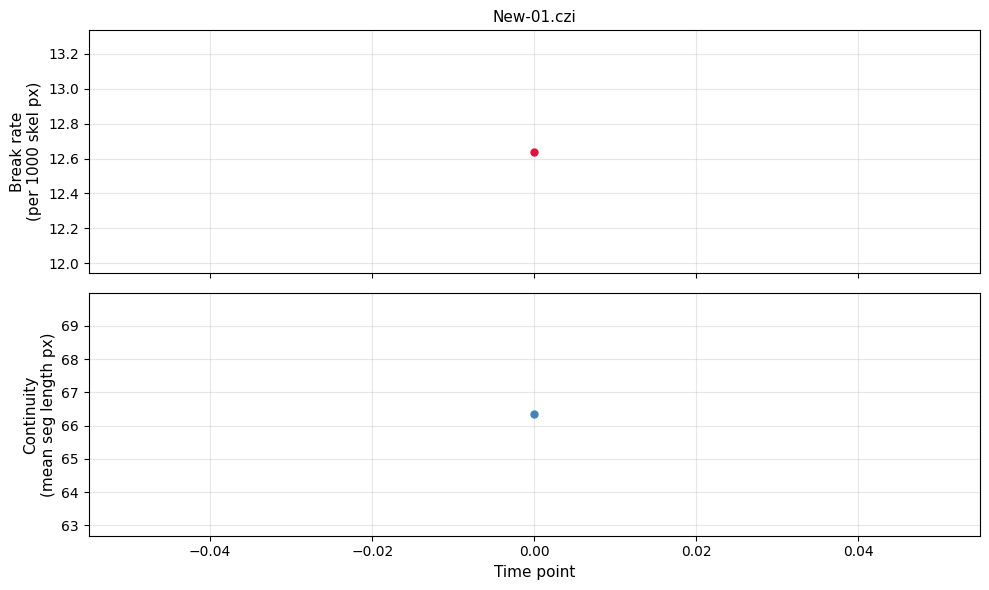

In [21]:
# ── Step 1: Analyse one file, plot over time ─────────────────────────────────
# Good starting point — check one file before running all three directories.
path_example = os.path.join(directory_1,
    sorted(f for f in os.listdir(directory_1) if f.endswith(".czi"))[0])

results_example = plot_timeseries(path_example, method='frangi')

## Step 2 — Visualise breaks at different time points

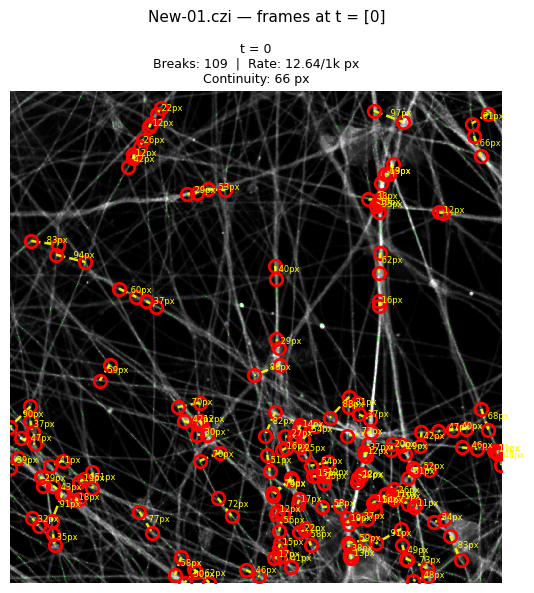

In [22]:
# ── Step 2: Show frames at selected time points ──────────────────────────────
# Visually verify that detected breaks make sense at different time points.
show_frames(path_example, t_indices=None, method='frangi')

## Step 3 — All files per condition
One overlay plot per directory — all files on same axes.

New-01.czi: 1 time points. done
New-02.czi: 1 time points. done
New-03.czi: 1 time points. done
New-04.czi: 1 time points. done
New-05.czi: 1 time points. done
New-06.czi: 1 time points. done
New-07.czi: 1 time points. done
New-08.czi: 1 time points. done
New-09.czi: 1 time points. done


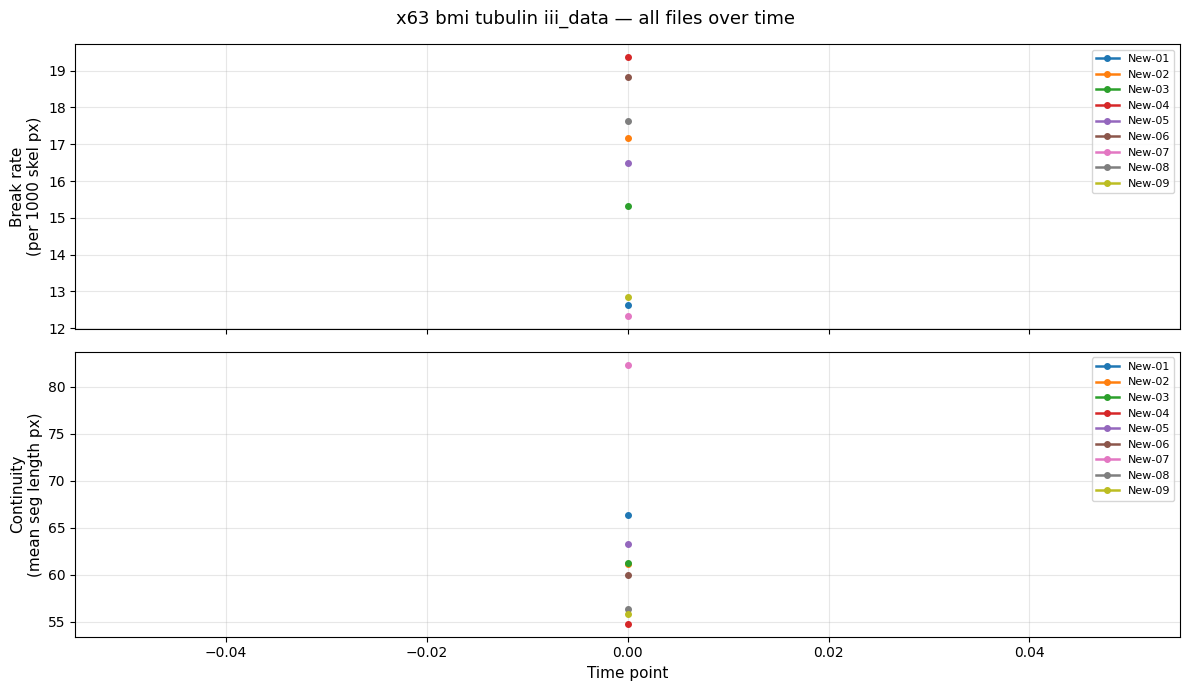

In [23]:
# ── Step 3: All files in directory_1 on one plot ─────────────────────────────
all_results_1 = plot_directory_timeseries(directory_1, method='frangi')

New-01.czi: 1 time points. done
New-02.czi: 1 time points. done
New-03.czi: 1 time points. done
New-04.czi: 1 time points. done


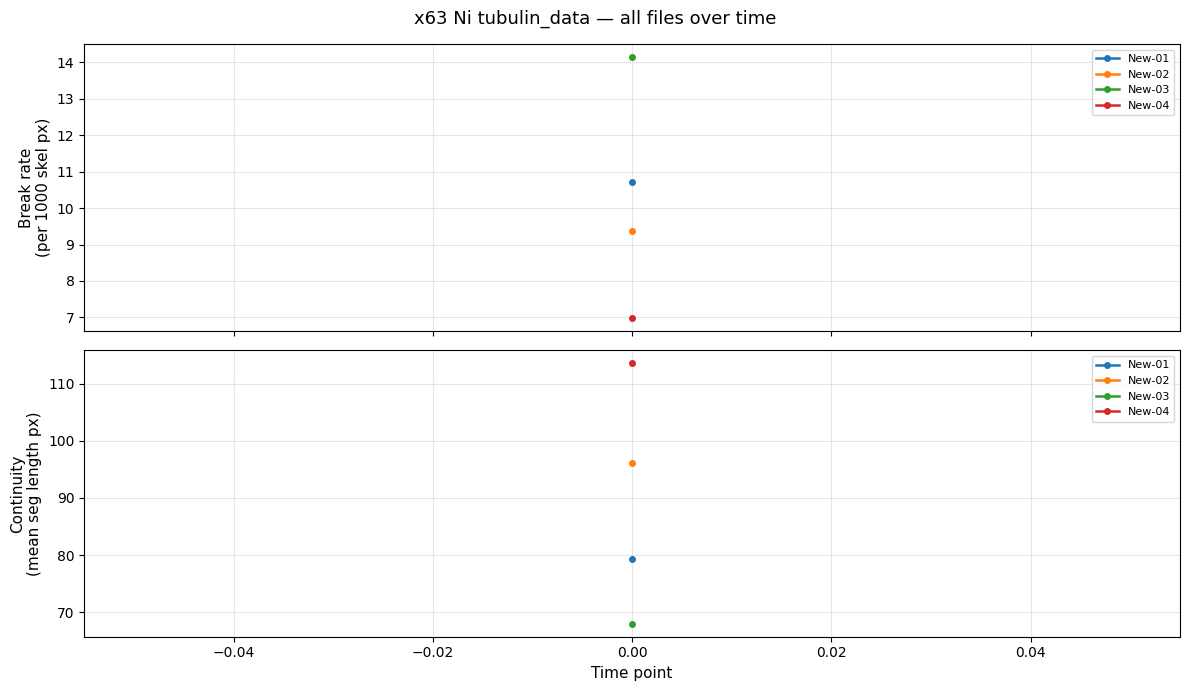

New-01.czi: 1 time points. done
New-02.czi: 1 time points. done
New-03.czi: 1 time points. done
New-04.czi: 1 time points. done


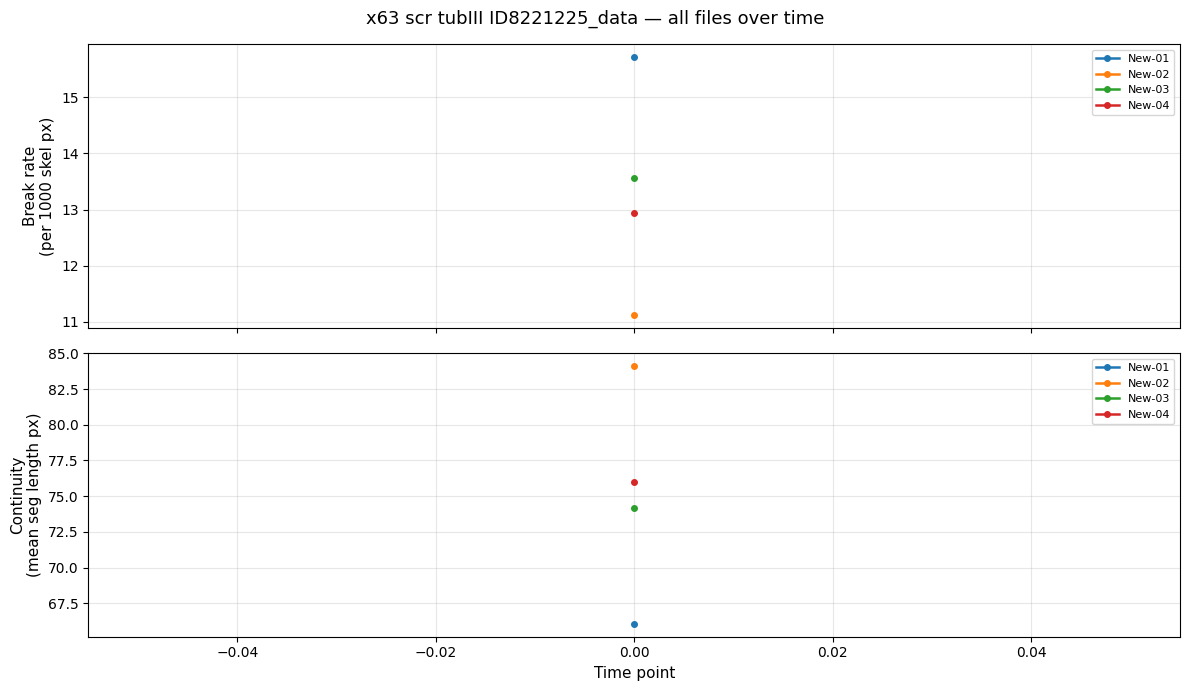

In [24]:
all_results_2 = plot_directory_timeseries(directory_2, method='frangi')
all_results_3 = plot_directory_timeseries(directory_3, method='frangi')

## Step 4 — Condition comparison over time
Main result: mean ± SEM per condition across the full time course.

New-01.czi: 1 time points. done
New-02.czi: 1 time points. done
New-03.czi: 1 time points. done
New-04.czi: 1 time points. done
New-05.czi: 1 time points. done
New-06.czi: 1 time points. done
New-07.czi: 1 time points. done
New-08.czi: 1 time points. done
New-09.czi: 1 time points. done
New-01.czi: 1 time points. done
New-02.czi: 1 time points. done
New-03.czi: 1 time points. done
New-04.czi: 1 time points. done
New-01.czi: 1 time points. done
New-02.czi: 1 time points. done
New-03.czi: 1 time points. done
New-04.czi: 1 time points. done


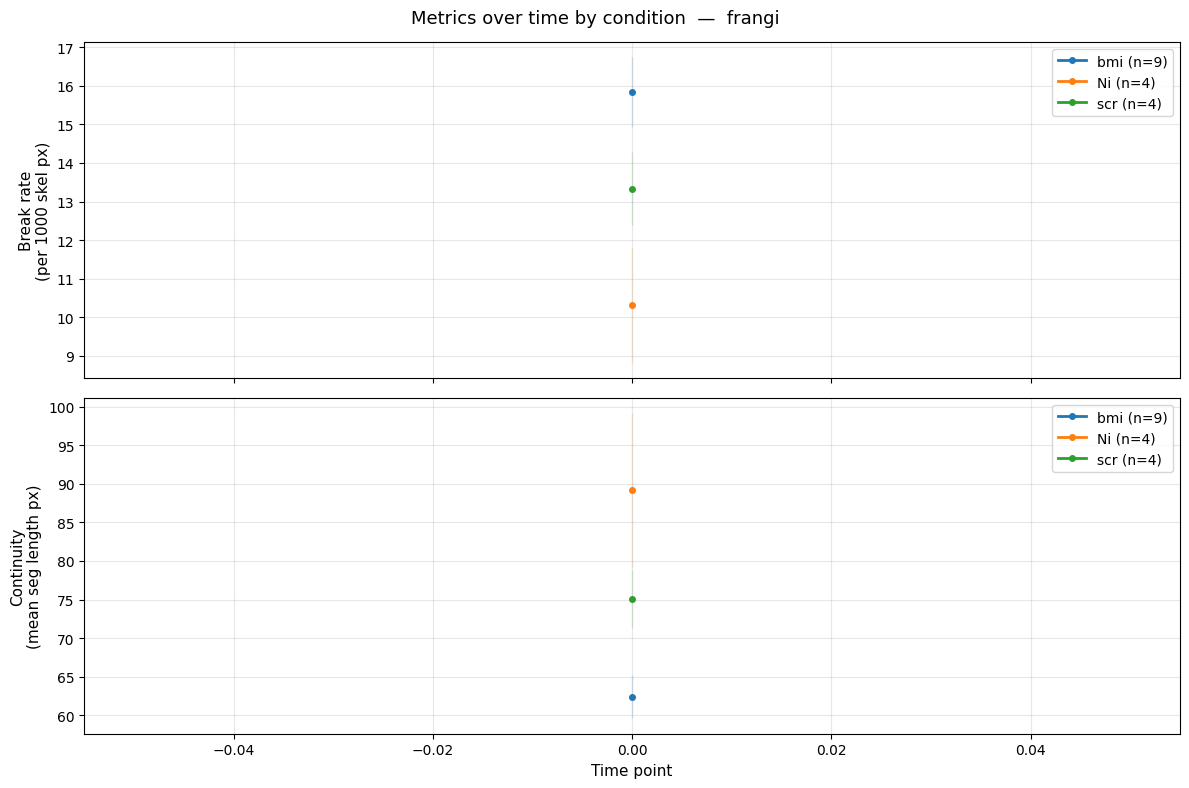

In [25]:
# ── Step 4: Compare all conditions over time ─────────────────────────────────
# Mean ± SEM band per condition — the main result plot.
plot_condition_comparison(
    directories={"bmi": directory_1, "Ni": directory_2, "scr": directory_3},
    method='frangi',
    min_gap=10, max_gap=100,
)